In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd

## Example of analysis from three searches
Note that the figures produced here mimic those shown in the paper, but are instead produced with a small, pilot set of searches (from the open-access MassSpecGym test set) that do not mean to represent either full benchmark. The following parsed results are first collected by running `python postprocessing/process_steps.py results/{sample_test_folder}`, which compiles statistics and other logged data across all spectra tested into TSVs for straightforward evaluation. 

Figure 4 plotting can be (most readily) made from the NDSBestMol 2D plots made in `evaluators.py`; these plot logs are currently silenced for storage efficiency but can be uncommented to have wandb save these plots for downstream visualization. All molecules are also logged in output_mols.yaml as part of the results files. 

TODO: update notebook state with additional results for closer similarity to benchmark. 


In [2]:
final_summaries = pd.read_csv("../results/compiled/summary.tsv", sep="\t")
timestep_stats = pd.read_csv("../results/compiled/timestep_summary.tsv", sep="\t")
per_step_logs = pd.read_csv("../results/compiled/steps.tsv", sep="\t")

In [3]:
valid_bins = final_summaries['best_seed_bin'].unique()

In [4]:
valid_bins

array(['(0.8, 1.0]', '(0.6, 0.8]'], dtype=object)

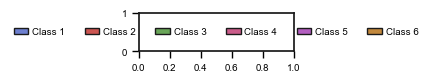

In [5]:
# takes about a minute 
from plotting_style import show_palette, PALETTE, styleset
styleset()
show_palette()

### Figure 2: review of trajectories

In [6]:
# from process_steps import build_dataframes, bootstrap_metrics_at_k

# # steps_df, summaries_df = build_dataframes("../results")

# if you want to bootstrap estimations, run this cell -- it can take a while. 
#boot_df = bootstrap_metrics_at_k(steps_df, k_steps=range(10),
# n_bootstrap=1000)



In [7]:
from fig_functions import * 

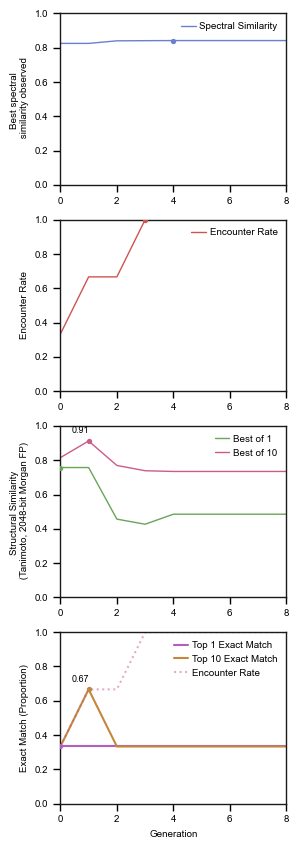

(<Figure size 300x850 with 4 Axes>,
 array([<Axes: ylabel='Best spectral \n similarity observed'>,
        <Axes: ylabel='Encounter Rate'>,
        <Axes: ylabel='Structural Similarity \n (Tanimoto, 2048-bit Morgan FP)'>,
        <Axes: xlabel='Generation', ylabel='Exact Match (Proportion)'>],
       dtype=object))

In [8]:

fig2_from_timestep_df(timestep_stats, error_bars=False, ci=False)

## Figure 3: Stratification of plots by seed similarity & oracle accuracy

The following plots are sparse since we have only preprocessed three spectra as examples here as a (very much not representative) subset of a larger dataset. 

In [9]:
final_summaries.columns.tolist()

['run_name',
 'InchiKeyMatch',
 'NDSBestMol',
 'NDSFronts',
 'TopNDSScore',
 'best_entropy',
 'SA_of_best_entropy',
 'top1_match',
 'top10_match',
 'NDSBestMol.better_SA_score_decoy',
 'NDSBestMol.better_entropy_decoy',
 'NDSBestMol.target_self_SA_score',
 'NDSBestMol.target_self_entropy',
 'NDSBestMol.top_10_entropy_better_than_target',
 'NDSBestMol.top_1_tani_similarity',
 'NDSBestMol.top_k_avg_tani_similarity',
 'NDSBestMol.top_k_max_tani_similarity',
 'InchiKeyMatch.InchiKeyMatch',
 'InchiKeyMatch.all_scores',
 'InchiKeyMatch.entropy_score',
 'InchiKeyMatch.front',
 'InchiKeyMatch.sample_num',
 'generation',
 'batch_size',
 'config',
 'debug',
 'denoise_specs',
 'device',
 'extra_seeds',
 'full_seed_file',
 'gen_model_ckpt',
 'gpu_workers',
 'iceberg_param',
 'ignore_precursor_peak',
 'inten_model_ckpt',
 'keep_population',
 'limited_evs',
 'log_freq',
 'max_calls',
 'max_nodes',
 'max_seed_sim',
 'merge_by_precursor_mz_inchi',
 'multiobj',
 'mutate_parents',
 'mutation_rate',
 'nc

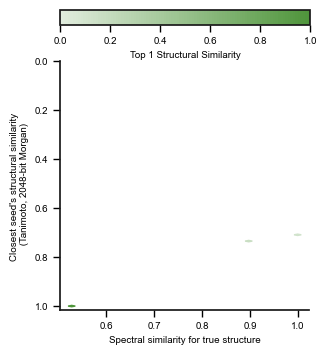

In [10]:
fig3a_hexplot(final_summaries) 

In [11]:
def add_rows(df):
    df = df.copy()
    for val in np.arange(0.05, 1, 0.05): 
        entry = {
            'best_seed_sim': val, 
            'NDSBestMol.target_self_entropy': val, 
            'top10_max_tani@3': val,
            'top10_match': np.random.uniform() < 0.5,
        }
        entry_df = pd.DataFrame([entry])
        df = pd.concat([df, entry_df], ignore_index=True)
    return df

final_summaries_dummy = add_rows(final_summaries)
final_summaries_dummy['best_seed_bin'] = pd.cut(final_summaries_dummy['best_seed_sim'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0])  
final_summaries_dummy['oracle_accuracy_bin'] = pd.cut(final_summaries_dummy['NDSBestMol.target_self_entropy'], bins=np.arange(0, 1.1, 0.2))
    

In [12]:
final_summaries_dummy

,run_name,InchiKeyMatch,NDSBestMol,NDSFronts,TopNDSScore,best_entropy,SA_of_best_entropy,top1_match,top10_match,NDSBestMol.better_SA_score_decoy,...,better_entropy_decoy@8,top1_entropy@9,inchikey_match@9,top1_tani@9,top10_max_tani@9,top1_match@9,top10_match@9,better_entropy_decoy@9,best_seed_bin,oracle_accuracy_bin
0,MassSpecGymID0393980,"{'InchiKeyMatch': 1, 'all_scores': [0.5274, 0....",{'NDSBestMol@1': 'CC1C(c2ccc(Cl)cc2)SC(=O)N1C(...,NaN,"{'TopNDSScore@1': [0.5274, 0.6852701566645095]...",0.527400,0.685270,1.0,1,1.0,...,0.0,0.527400,1.0,1.000000,1.000000,1.0,1.0,0.0,"(0.8, 1.0]","(0.4, 0.6]"
1,MassSpecGymID0230986,"{'InchiKeyMatch': 1, 'all_scores': [0.89607100...",{'NDSBestMol@1': 'COc1ccc(C2=Cc3cnc(N)nc3N=CN2...,NaN,"{'TopNDSScore@1': [0.998864, 0.675066488617108...",0.998864,0.675066,0.0,0,0.0,...,1.0,0.998864,1.0,0.342105,0.531250,0.0,0.0,1.0,"(0.6, 0.8]","(0.8, 1.0]"
2,MassSpecGymID0220772,"{'InchiKeyMatch': 1, 'all_scores': [1.0, 0.714...",{'NDSBestMol@1': 'CC(C)n1ccc(Nc2nc(NCCO)nc(Nc3...,NaN,"{'TopNDSScore@1': [1.0, 0.7464408664382495], '...",1.000000,0.746441,0.0,0,1.0,...,0.0,1.000000,1.0,0.113924,0.672727,0.0,0.0,0.0,"(0.6, 0.8]","(0.8, 1.0]"
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(0.0, 0.2]","(0.0, 0.2]"
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(0.0, 0.2]","(0.0, 0.2]"
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(0.0, 0.2]","(0.0, 0.2]"
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(0.0, 0.2]","(0.0, 0.2]"
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(0.2, 0.4]","(0.2, 0.4]"
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(0.2, 0.4]","(0.2, 0.4]"
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(0.2, 0.4]","(0.2, 0.4]"


[(0.8, 1.0], (0.6, 0.8], (0.0, 0.2], (0.2, 0.4], (0.4, 0.6]]
Categories (5, interval[float64, right]): [(0.0, 0.2] < (0.2, 0.4] < (0.4, 0.6] < (0.6, 0.8] < (0.8, 1.0]]
[Interval(0.0, 0.2, closed='right'), Interval(0.2, 0.4, closed='right'), Interval(0.4, 0.6, closed='right'), Interval(0.6, 0.8, closed='right'), Interval(0.8, 1.0, closed='right')]


/home/mrunali/miniconda3/envs/ms-gen-cu12/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)
/home/mrunali/miniconda3/envs/ms-gen-cu12/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)
/home/mrunali/miniconda3/envs/ms-gen-cu12/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)
/home/mrunali/miniconda3/envs/ms-gen-cu12/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*

(False, <seaborn.axisgrid.FacetGrid at 0x7fe29ff7b9d0>)

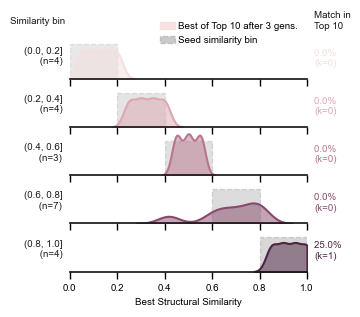

In [13]:
fig3b_plot_seed_kde(final_summaries_dummy,
                    cols_to_plot=['top10_max_tani'],
                    success_col='top10_match', k=3)

/home/mrunali/miniconda3/envs/ms-gen-cu12/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)
/home/mrunali/miniconda3/envs/ms-gen-cu12/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)
/home/mrunali/miniconda3/envs/ms-gen-cu12/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self._figure.tight_layout(*args, **kwargs)


(0.0, 0.2]
(0.2, 0.4]
(0.4, 0.6]
(0.6, 0.8]
(0.8, 1.0]


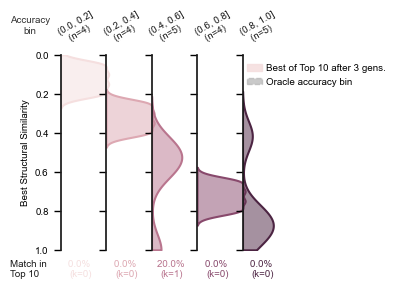

In [14]:
fig3c_plot_oracle_kde(final_summaries_dummy,
                    cols_to_plot=['top10_max_tani'],
                    success_col='top10_match', k=3)

In [ ]:
fig3d_plot_roc_curve(per_step_logs, final_summaries)